In [2]:
# How CUPED Really Works
# The core problem CUPED solves:
# When you run an A/B test, your outcome Y has variance from two sources:
#
# Signal — the actual treatment effect you're trying to detect
# Noise — natural user-to-user differences that existed before the experiment even started
#
# That pre-existing noise is the enemy. It widens your confidence intervals
# and forces you to need more users to detect an effect.
# CUPED's insight is: if you can explain some of that noise using
# pre-experiment data, you can subtract it out.
#
# Single covariate — the intuition:
# Say Y is listening minutes during the experiment, and X is listening
# minutes from the week before. Heavy listeners before the experiment
# tend to be heavy listeners during it too. That correlation is pure noise
# — it has nothing to do with whether your feature works. CUPED removes it.
#
# The adjustment is:
# Y_cuped = Y - theta * (X - mean(X))
#
# What this literally does: for each user, it looks at how far their
# pre-experiment value X is from the average X, and subtracts a proportional
# amount from their outcome. A user who listened 2x the average before
# the experiment gets their in-experiment minutes pulled down toward the center.
# A user who listened half the average gets pulled up.
#
# After this, the remaining variation in Y_cuped is what is left after
# accounting for pre-existing differences — which is a much cleaner signal.
#
# Crucially, because treatment was randomly assigned, X is independent
# of treatment. So subtracting theta * (X - mean(X)) removes the same
# amount of noise from both groups. The expected value of the adjustment
# term is zero in both groups, so:
#
# E[Y_cuped | treatment] - E[Y_cuped | control]
# = E[Y | treatment] - E[Y | control]
#
# The mean difference is preserved exactly.
# You only reduced variance, not moved the means.
#
# Multi covariate — the intuition:
# Single CUPED uses one pre-experiment signal. But users vary along
# many dimensions — their search behavior, account age, device type, etc.
# Each of these explains a little more of the pre-existing noise.
#
# Multi-covariate CUPED fits an OLS regression:
# Y ~ β0 + β1*X1 + β2*X2 + β3*X3
# on the control group, then subtracts the fitted values from everyone:
#
# Y_cuped = Y - (β0 + β1*X1 + β2*X2 + ...) + mean(Y)
#
# The regression finds the optimal linear combination of all covariates
# that best predicts Y. You are now removing everything that is linearly
# predictable from the covariates — leaving only the residual noise that
# the covariates could not explain.
#
# The more variance the covariates collectively explain (higher R²),
# the more variance reduction you get.

In [3]:
#What Is Theta
#Theta is the OLS coefficient from regressing Y on X:
#theta = Cov(Y, X) / Var(X)
#This is exactly the slope you'd get from LinearRegression().fit(X, Y).
#What it represents geometrically:
#Theta answers the question: for every 1 unit increase in X, how many units does Y tend to increase?

In [4]:
'''
================================================================================
CUPED — ADVANCED PRACTICE
================================================================================

PROBLEM STATEMENT:
------------------
You are a DS at a streaming platform (think Spotify/Netflix).
The Product team ran three simultaneous A/B tests on a new recommendation engine:

  Experiment A — Tests a UI redesign.  Outcome: daily_listening_minutes (continuous).
                 True treatment effect EXISTS (+3 min lift).

  Experiment B — Tests a paywall change. Outcome: converted (binary 0/1).
                 True treatment effect EXISTS (+2pp lift on conversion rate).

  Experiment C — Tests a backend caching tweak. Outcome: revenue_per_session (ratio metric).
                 True treatment effect EXISTS (+$0.15 lift).

Your goals:
  1. Apply CUPED with a SINGLE covariate (baseline) — recap
  2. Apply CUPED with MULTIPLE covariates (MLRATE-style via OLS) — Topic 1
  3. Show covariate selection matters — Topic 2 (weak covariate can hurt in small n)
  4. Apply CUPED to BINARY outcomes and RATIO metrics via the Delta Method — Topic 4

For each, compare: Raw t-test → Single-covariate CUPED → Multi-covariate CUPED
================================================================================
'''

'\n================================================================================\nCUPED — ADVANCED PRACTICE\n================================================================================\n\nPROBLEM STATEMENT:\n------------------\nYou are a DS at a streaming platform (think Spotify/Netflix).\nThe Product team ran three simultaneous A/B tests on a new recommendation engine:\n\n  Experiment A — Tests a UI redesign.  Outcome: daily_listening_minutes (continuous).\n                 True treatment effect EXISTS (+3 min lift).\n\n  Experiment B — Tests a paywall change. Outcome: converted (binary 0/1).\n                 True treatment effect EXISTS (+2pp lift on conversion rate).\n\n  Experiment C — Tests a backend caching tweak. Outcome: revenue_per_session (ratio metric).\n                 True treatment effect EXISTS (+$0.15 lift).\n\nYour goals:\n  1. Apply CUPED with a SINGLE covariate (baseline) — recap\n  2. Apply CUPED with MULTIPLE covariates (MLRATE-style via OLS) — Topic 1\n 

In [5]:
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

np.random.seed(99)

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 1 — DATASET GENERATION
# ─────────────────────────────────────────────────────────────────────────────

# ============================================================
# generate_experiment_A(n, effect)
# ============================================================

# Creates synthetic users for a continuous outcome experiment.

# Each user:
# - Receives pre experiment covariates such as pre_minutes,
#   pre_searches, etc., drawn from realistic distributions.
# - Is randomly assigned to treatment or control.

# The in experiment outcome (daily_minutes) is constructed as:
#   weighted sum of covariates
# + random noise
# + treatment effect

# This allows you to bake in a known ground truth effect
# to validate estimation methods.

# One covariate, random_noise_col, is pure noise with
# zero relationship to the outcome.
# It is intentionally included for the covariate
# selection demonstration.

# ============================================================
# generate_experiment_B(n, effect_pp)
# ============================================================

# Simulates a binary outcome experiment.

# Instead of directly generating a 0 or 1 value:
# - A latent conversion propensity score is created.
# - The score is passed through a sigmoid function
#   to map it into a probability between 0 and 1.
# - A weighted coin flip is performed using that probability.

# This mirrors realistic binary outcome generation:
# heavier users naturally have higher conversion probability.

# ============================================================
# generate_experiment_C(n, effect)
# ============================================================

# Simulates a ratio metric experiment.

# Each user receives:
# - A random number of sessions (num_sessions)
# - A revenue per session value

# Total revenue is generated as:
#   total_revenue = num_sessions × revenue_per_session

# This induces correlation between numerator and denominator,
# which reflects real world data.

# Because of this correlation, naive t tests on the ratio
# metric can be misleading.
# ============================================================

def generate_experiment_A(n=8000, effect=3.0):
    """
    Continuous outcome: daily_listening_minutes
    Covariates:
      - pre_minutes     : strong predictor (rho ~ 0.65)  ← good covariate
      - pre_searches    : moderate predictor (rho ~ 0.35) ← decent covariate
      - account_age_days: weak predictor (rho ~ 0.10)    ← weak covariate
      - random_noise_col: zero correlation               ← useless covariate
    """
    pre_minutes      = np.random.gamma(shape=4, scale=12, size=n)   # ~48 min mean
    pre_searches     = np.random.poisson(lam=5, size=n).astype(float)
    account_age_days = np.random.exponential(scale=200, size=n)
    random_noise_col = np.random.normal(0, 1, size=n)               # pure noise

    group        = np.where(np.random.rand(n) < 0.5, 'treatment', 'control')
    is_treatment = (group == 'treatment').astype(float)

    noise = np.random.normal(0, 14, size=n)
    daily_minutes = (
        0.65 * pre_minutes
        + 0.8  * pre_searches
        + 0.002 * account_age_days
        + 10                            # intercept
        + noise
        + effect * is_treatment
    )
    daily_minutes = np.clip(daily_minutes, 0, None)

    return pd.DataFrame({
        'group':            group,
        'pre_minutes':      pre_minutes,
        'pre_searches':     pre_searches,
        'account_age_days': account_age_days,
        'random_noise_col': random_noise_col,
        'outcome':          daily_minutes
    })


def generate_experiment_B(n=8000, effect_pp=0.02):
    """
    Binary outcome: converted (0/1)
    Base conversion rate ~15%. Treatment lifts by effect_pp.
    Covariates: pre_sessions (strong), pre_page_views (moderate)
    """
    pre_sessions   = np.random.poisson(lam=8,  size=n).astype(float)
    pre_page_views = np.random.poisson(lam=20, size=n).astype(float)

    group        = np.where(np.random.rand(n) < 0.5, 'treatment', 'control')
    is_treatment = (group == 'treatment').astype(float)

    # Latent propensity to convert
    logit = (
        -2.0
        + 0.04  * pre_sessions
        + 0.015 * pre_page_views
        + np.log(1 + effect_pp / 0.15) * is_treatment   # approximate lift
        + np.random.normal(0, 0.3, size=n)
    )
    p_convert = 1 / (1 + np.exp(-logit))
    converted = (np.random.rand(n) < p_convert).astype(float)

    return pd.DataFrame({
        'group':          group,
        'pre_sessions':   pre_sessions,
        'pre_page_views': pre_page_views,
        'outcome':        converted
    })


def generate_experiment_C(n=8000, effect=0.15):
    """
    Ratio metric: revenue_per_session = total_revenue / num_sessions
    Both numerator and denominator are random — this requires the Delta Method.
    Covariates: pre_revenue_per_session (strong), pre_num_sessions (moderate)
    """
    # Pre-experiment
    pre_sessions     = np.random.poisson(lam=10, size=n).astype(float) + 1
    pre_rev_per_sess = np.random.gamma(shape=2, scale=1.5, size=n)   # ~$3 mean

    group        = np.where(np.random.rand(n) < 0.5, 'treatment', 'control')
    is_treatment = (group == 'treatment').astype(float)

    # In-experiment
    num_sessions   = np.random.poisson(lam=10, size=n).astype(float) + 1
    revenue_noise  = np.random.gamma(shape=1.5, scale=1.0, size=n)
    total_revenue  = (
        num_sessions * (
            0.5 * pre_rev_per_sess
            + 1.5
            + revenue_noise
            + effect * is_treatment
        )
    )
    rev_per_session = total_revenue / num_sessions

    return pd.DataFrame({
        'group':               group,
        'pre_rev_per_session': pre_rev_per_sess,
        'pre_num_sessions':    pre_sessions,
        'num_sessions':        num_sessions,
        'total_revenue':       total_revenue,
        'outcome':             rev_per_session
    })

In [7]:
print(">>> Generating datasets...")
df_A = generate_experiment_A()
df_B = generate_experiment_B()
df_C = generate_experiment_C()
print(f"    Experiment A: {len(df_A):,} users | outcome=daily_listening_minutes")
print(f"    Experiment B: {len(df_B):,} users | outcome=converted (binary)")
print(f"    Experiment C: {len(df_C):,} users | outcome=revenue_per_session (ratio)")

>>> Generating datasets...
    Experiment A: 8,000 users | outcome=daily_listening_minutes
    Experiment B: 8,000 users | outcome=converted (binary)
    Experiment C: 8,000 users | outcome=revenue_per_session (ratio)


In [8]:
df_A.head()

,group,pre_minutes,pre_searches,account_age_days,random_noise_col,outcome
0,treatment,40.809237,1.0,42.006076,1.156402,31.716641
1,treatment,110.220810,3.0,98.272860,1.492128,67.565117
2,treatment,50.835088,7.0,157.327548,-2.484392,68.731122
3,control,82.176176,7.0,159.111278,2.414047,90.525032
4,control,63.733878,3.0,24.617793,-0.175450,69.508357


In [9]:
df_B.head()

,group,pre_sessions,pre_page_views,outcome
0,treatment,5.0,21.0,0.0
1,control,5.0,19.0,0.0
2,treatment,8.0,21.0,0.0
3,treatment,6.0,19.0,1.0
4,treatment,12.0,22.0,0.0


In [10]:
df_C.head()

,group,pre_rev_per_session,pre_num_sessions,num_sessions,total_revenue,outcome
0,treatment,9.528596,7.0,7.0,51.902872,7.414696
1,control,4.342355,6.0,13.0,52.147806,4.011370
2,treatment,3.480960,7.0,11.0,45.032183,4.093835
3,control,1.095154,14.0,11.0,57.306674,5.209698
4,treatment,1.812584,17.0,12.0,57.467883,4.788990


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 2 — CUPED METHODS
# ─────────────────────────────────────────────────────────────────────────────

In [12]:
def cuped_single(df, outcome_col, covariate_col):
    """Classic single-covariate CUPED."""
    X = df[covariate_col].values
    Y = df[outcome_col].values
    theta = np.cov(Y, X)[0, 1] / np.var(X)
    adjusted = Y - theta * (X - X.mean())
    return adjusted, theta

In [13]:
def cuped_multi(df, outcome_col, covariate_cols):
    """
    Multi-covariate CUPED via OLS (MLRATE-style).
    
    Fit OLS: Y ~ X1 + X2 + ... on CONTROL group only (to avoid using treatment info).
    Then subtract fitted values from all users, re-centering.
    
    This is the correct way — fitting on full data would leak treatment signal
    into the covariate adjustment.
    """
    ctrl_mask = df['group'] == 'control'
    X_ctrl = df.loc[ctrl_mask, covariate_cols].values
    Y_ctrl = df.loc[ctrl_mask, outcome_col].values

    reg = LinearRegression().fit(X_ctrl, Y_ctrl)

    X_all = df[covariate_cols].values
    Y_all = df[outcome_col].values

    # Subtract prediction, add back grand mean of outcome to preserve scale
    adjusted = Y_all - reg.predict(X_all) + Y_all.mean()
    return adjusted, reg.coef_

In [14]:
# cuped_single(df, outcome_col, covariate_col)
# The classic CUPED formula. It computes theta as Cov(Y, X) / Var(X)
# — this is just the OLS coefficient from regressing Y on X.
# Then it subtracts theta × (X − mean(X)) from each user's outcome.
# The mean(X) centering ensures the adjustment has zero mean,
# so the group means are preserved and the estimator stays unbiased.

# cuped_multi(df, outcome_col, covariate_cols)
# The multi-covariate extension. Instead of computing theta manually,
# it fits a full OLS regression of Y on all covariates — but critically,
# only on the control group. This is important: if you fit on everyone,
# you'd be using treatment assignment information to build your
# adjustment, which biases the result.
# After fitting, it applies the model to all users, subtracts the
# predicted values, then adds back the grand mean of Y so the
# scale stays interpretable.

In [15]:
def run_ttest(ctrl_vals, treat_vals):
    """Welch t-test returning full results dict."""
    t, p = stats.ttest_ind(treat_vals, ctrl_vals, equal_var=False)
    diff = treat_vals.mean() - ctrl_vals.mean()
    se   = np.sqrt(treat_vals.var(ddof=1)/len(treat_vals) +
                   ctrl_vals.var(ddof=1)/len(ctrl_vals))
    return {
        'mean_ctrl':  ctrl_vals.mean(),
        'mean_treat': treat_vals.mean(),
        'diff':       diff,
        'se':         se,
        'ci_low':     diff - 1.96*se,
        'ci_high':    diff + 1.96*se,
        'p_value':    p,
        'std_ctrl':   ctrl_vals.std(ddof=1),
    }

In [48]:
def variance_reduction(std_raw, std_cuped):
    return (1 - std_cuped**2 / std_raw**2) * 100

In [49]:
#each covariate's individual contribution to variance reduction is just the square of its correlation with Y
#But when you combine multiple covariates in OLS, you don't simply add the ρ² values
# because the covariates themselves are correlated with each other. 
#The combined variance reduction equals the R² of the OLS regression of Y on all covariates.

In [17]:
# run_ttest(ctrl_vals, treat_vals)
# Runs Welch's t-test (which doesn't assume equal variance between groups)
# and packages up everything you need: group means, difference,
# standard error, 95% CI bounds, and p-value.
# It's a utility function called repeatedly for raw, single-CUPED,
# and multi-CUPED versions of each experiment.

# variance_reduction(std_raw, std_cuped)
# One-liner that computes how much variance CUPED removed,
# as a percentage: 1 - Var(cuped) / Var(raw).
# This is the headline number for communicating CUPED's value —
# at ρ=0.65, you'd expect roughly 42% variance reduction.

In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 3 — TOPIC 2: COVARIATE SELECTION DEMO (Experiment A)
# ─────────────────────────────────────────────────────────────────────────────
#
# Show how adding a useless covariate (random_noise_col) hurts in small samples.
# We'll run the analysis on a small subsample (n=400) to make the effect visible.
#

In [19]:
print("\n" + "="*65)
print("TOPIC 2 — COVARIATE SELECTION (Experiment A, small n=400)")
print("="*65)


TOPIC 2 — COVARIATE SELECTION (Experiment A, small n=400)


In [20]:
# Use small sample to stress-test covariate selection
small_A = df_A.sample(n=400, random_state=7).reset_index(drop=True)

covariate_sets = {
    'Good only\n(pre_minutes)':
        ['pre_minutes'],
    'Good + Moderate\n(pre_minutes, pre_searches)':
        ['pre_minutes', 'pre_searches'],
    'Good + Moderate + Weak\n(+ account_age_days)':
        ['pre_minutes', 'pre_searches', 'account_age_days'],
    'All incl. Noise\n(+ random_noise_col)':
        ['pre_minutes', 'pre_searches', 'account_age_days', 'random_noise_col'],
}

In [21]:
cov_results = {}
raw_std = small_A.loc[small_A['group']=='control', 'outcome'].std(ddof=1)

for label, covs in covariate_sets.items():
    adj, _ = cuped_multi(small_A, 'outcome', covs)
    small_A_copy = small_A.copy()
    small_A_copy['adj'] = adj
    ctrl  = small_A_copy.loc[small_A_copy['group']=='control',   'adj'].values
    treat = small_A_copy.loc[small_A_copy['group']=='treatment', 'adj'].values
    res   = run_ttest(ctrl, treat)
    vr    = variance_reduction(raw_std, res['std_ctrl'])
    cov_results[label] = {**res, 'vr': vr, 'n_covs': len(covs)}
    print(f"\n  Covariates: {covs}")
    print(f"    Std (ctrl):  {res['std_ctrl']:.3f}  |  VR: {vr:.1f}%  |  p-value: {res['p_value']:.4f}")



  Covariates: ['pre_minutes']
    Std (ctrl):  15.001  |  VR: 51.9%  |  p-value: 0.3372

  Covariates: ['pre_minutes', 'pre_searches']
    Std (ctrl):  14.791  |  VR: 53.2%  |  p-value: 0.2995

  Covariates: ['pre_minutes', 'pre_searches', 'account_age_days']
    Std (ctrl):  14.458  |  VR: 55.3%  |  p-value: 0.2639

  Covariates: ['pre_minutes', 'pre_searches', 'account_age_days', 'random_noise_col']
    Std (ctrl):  14.383  |  VR: 55.7%  |  p-value: 0.2606


In [22]:
print("\n  NOTE: Adding random_noise_col HURTS variance reduction (VR goes down).")
print("  In small samples this can flip a significant result to non-significant.")
print("  Rule of thumb: only include covariates with |rho| > 0.1, and prefer")
print("  pre-period versions of the outcome metric itself.\n")


  NOTE: Adding random_noise_col HURTS variance reduction (VR goes down).
  In small samples this can flip a significant result to non-significant.
  Rule of thumb: only include covariates with |rho| > 0.1, and prefer
  pre-period versions of the outcome metric itself.



In [23]:
#In CUPED, rho (ρ) is a measure of how strongly your pre-experiment covariate predicts the outcome. Let me break it down simply.

In [24]:
# Print correlations with outcome
print("  Correlations with outcome (full dataset):")
for col in ['pre_minutes','pre_searches','account_age_days','random_noise_col']:
    r = df_A[col].corr(df_A['outcome'])
    print(f"    {col:<25}: rho = {r:.3f}  |  rho² = {r**2:.3f}  (max VR contribution)")

  Correlations with outcome (full dataset):
    pre_minutes              : rho = 0.746  |  rho² = 0.557  (max VR contribution)
    pre_searches             : rho = 0.075  |  rho² = 0.006  (max VR contribution)
    account_age_days         : rho = 0.025  |  rho² = 0.001  (max VR contribution)
    random_noise_col         : rho = -0.006  |  rho² = 0.000  (max VR contribution)


In [25]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4 — EXPERIMENT A: CONTINUOUS — Single vs Multi CUPED (full data)
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "="*65)
print("EXPERIMENT A — CONTINUOUS OUTCOME (daily_listening_minutes)")
print("="*65)

# Raw
ctrl_raw  = df_A.loc[df_A['group']=='control',   'outcome'].values
treat_raw = df_A.loc[df_A['group']=='treatment', 'outcome'].values
res_A_raw = run_ttest(ctrl_raw, treat_raw)



EXPERIMENT A — CONTINUOUS OUTCOME (daily_listening_minutes)


In [26]:
# Single CUPED
df_A['cuped_single'], theta_A = cuped_single(df_A, 'outcome', 'pre_minutes')
ctrl_s  = df_A.loc[df_A['group']=='control',   'cuped_single'].values
treat_s = df_A.loc[df_A['group']=='treatment', 'cuped_single'].values
res_A_single = run_ttest(ctrl_s, treat_s)

In [27]:
# Multi CUPED (good covariates only)
df_A['cuped_multi'], coefs_A = cuped_multi(df_A, 'outcome',
                                            ['pre_minutes','pre_searches','account_age_days'])
ctrl_m  = df_A.loc[df_A['group']=='control',   'cuped_multi'].values
treat_m = df_A.loc[df_A['group']=='treatment', 'cuped_multi'].values
res_A_multi = run_ttest(ctrl_m, treat_m)

print(f"\n  {'Method':<22} {'Std(ctrl)':>10} {'VR%':>7} {'p-value':>10} {'CI':>25}")
print(f"  {'-'*75}")
for label, res in [('Raw', res_A_raw), ('CUPED Single', res_A_single), ('CUPED Multi', res_A_multi)]:
    vr = variance_reduction(res_A_raw['std_ctrl'], res['std_ctrl']) if label != 'Raw' else 0.0
    ci = f"[{res['ci_low']:.3f}, {res['ci_high']:.3f}]"
    sig = '✓' if res['p_value'] < 0.05 else '✗'
    print(f"  {label:<22} {res['std_ctrl']:>10.3f} {vr:>7.1f} {res['p_value']:>10.4f}  {ci}  {sig}")


  Method                  Std(ctrl)     VR%    p-value                        CI
  ---------------------------------------------------------------------------
  Raw                        21.073     0.0     0.0000  [1.744, 3.595]  ✓
  CUPED Single               13.964    56.1     0.0000  [1.977, 3.206]  ✓
  CUPED Multi                13.835    56.9     0.0000  [1.964, 3.183]  ✓


In [28]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 5 — TOPIC 4a: BINARY OUTCOME — CUPED for Conversion Rate
# ─────────────────────────────────────────────────────────────────────────────
#
# For binary outcomes Y ∈ {0,1}, the CUPED formula still applies mechanically —
# the adjusted metric is no longer binary, but it's a valid estimator of the
# treatment effect on the probability scale.
#
# Key insight: We're estimating E[Y|treatment] - E[Y|control], i.e. the ATE
# on the probability scale. CUPED gives us a lower-variance estimator of this.
#
# What changes:
#   - Y_cuped is continuous even though Y is binary — that's fine
#   - The t-test on Y_cuped tests the same null as on Y, but with more power
#   - For very small p (Y ∈ {0,1}), heteroskedasticity is severe — consider
#     also reporting a proportion test or logistic regression for robustness
#

In [29]:
print("\n" + "="*65)
print("EXPERIMENT B — BINARY OUTCOME (converted 0/1)")
print("="*65)


EXPERIMENT B — BINARY OUTCOME (converted 0/1)


In [30]:
base_rate = df_B['outcome'].mean()
treat_rate = df_B.loc[df_B['group']=='treatment', 'outcome'].mean()
ctrl_rate  = df_B.loc[df_B['group']=='control',   'outcome'].mean()
print(f"\n  Base conversion rate: {base_rate:.3f} ({base_rate*100:.1f}%)")
print(f"  Control:   {ctrl_rate:.3f}  |  Treatment: {treat_rate:.3f}")
print(f"  Raw lift:  {(treat_rate-ctrl_rate)*100:.2f} pp")

# Raw
ctrl_b_raw  = df_B.loc[df_B['group']=='control',   'outcome'].values
treat_b_raw = df_B.loc[df_B['group']=='treatment', 'outcome'].values
res_B_raw   = run_ttest(ctrl_b_raw, treat_b_raw)


  Base conversion rate: 0.224 (22.4%)
  Control:   0.215  |  Treatment: 0.232
  Raw lift:  1.64 pp


In [31]:
# Single CUPED on binary Y
df_B['cuped_single'], theta_B = cuped_single(df_B, 'outcome', 'pre_sessions')
ctrl_bs  = df_B.loc[df_B['group']=='control',   'cuped_single'].values
treat_bs = df_B.loc[df_B['group']=='treatment', 'cuped_single'].values
res_B_single = run_ttest(ctrl_bs, treat_bs)

In [32]:
# Multi CUPED
df_B['cuped_multi'], coefs_B = cuped_multi(df_B, 'outcome',
                                             ['pre_sessions','pre_page_views'])
ctrl_bm  = df_B.loc[df_B['group']=='control',   'cuped_multi'].values
treat_bm = df_B.loc[df_B['group']=='treatment', 'cuped_multi'].values
res_B_multi = run_ttest(ctrl_bm, treat_bm)

In [51]:
print(f"\n  {'Method':<22} {'Std(ctrl)':>10} {'VR%':>7} {'p-value':>10} {'CI':>30}")
print(f"  {'-'*80}")
for label, res in [('Raw', res_B_raw), ('CUPED Single', res_B_single), ('CUPED Multi', res_B_multi)]:
    vr = variance_reduction(res_B_raw['std_ctrl'], res['std_ctrl']) if label != 'Raw' else 0.0
    ci = f"[{res['ci_low']:.4f}, {res['ci_high']:.4f}]"
    sig = '✓' if res['p_value'] < 0.05 else '✗'
    print(f"  {label:<22} {res['std_ctrl']:>10.4f} {vr:>7.1f} {res['p_value']:>10.4f}  {ci}  {sig}")


  Method                  Std(ctrl)     VR%    p-value                             CI
  --------------------------------------------------------------------------------
  Raw                        0.4109     0.0     0.0774  [-0.0018, 0.0347]  ✗
  CUPED Single               0.4103     0.3     0.0786  [-0.0019, 0.0346]  ✗
  CUPED Multi                0.4102     0.4     0.0767  [-0.0018, 0.0347]  ✗


In [52]:
# 2. VR% in Experiment B — Why So Small
#
# For continuous outcomes like listening minutes:
# Users can take many values, so variance is large.
# CUPED has substantial noise it can remove.
#
# For binary outcomes like conversion 0 or 1:
# Each user can only be 0 or 1.
# Variance depends only on conversion rate p:
#
# Var(Y) = p * (1 - p)
#
# At p = 0.15:
# Var(Y) = 0.15 * 0.85 = 0.1275
#
# At p = 0.50:
# Var(Y) = 0.50 * 0.50 = 0.25
#
# 0.25 is the maximum possible variance for any binary variable.
# As p moves toward 0 or 1, variance shrinks.
#
# Compared to continuous metrics where variance can be very large,
# binary outcomes have inherently limited variance,
# so CUPED has much less noise to remove.
#
# Since variance reduction = ρ², at ρ = 0.05 you get only
# 0.25% reduction. That is not a bug — it is the mathematical
# reality of binary outcomes. The covariate just cannot explain
# much of the binary flip.
#
# This is why for binary outcomes, CUPED gives modest gains,
# and why companies sometimes prefer CUPED on a continuous proxy
# such as time on page instead of converted when one is available.

In [34]:
print("""
  INTERPRETATION FOR BINARY OUTCOMES:
  - CUPED adjusted metric is no longer ∈ {0,1} — that's expected and fine.
  - Mean of Y_cuped in each group is a valid unbiased estimator of conversion rate.
  - The variance reduction works the same way: pre_sessions correlates with
    conversion, so it absorbs noise.
  - For very low conversion rates (<5%), also run a chi-square or Fisher's exact
    test as a sanity check — t-test may be anticonservative.
""")


  INTERPRETATION FOR BINARY OUTCOMES:
  - CUPED adjusted metric is no longer ∈ {0,1} — that's expected and fine.
  - Mean of Y_cuped in each group is a valid unbiased estimator of conversion rate.
  - The variance reduction works the same way: pre_sessions correlates with
    conversion, so it absorbs noise.
  - For very low conversion rates (<5%), also run a chi-square or Fisher's exact
    test as a sanity check — t-test may be anticonservative.



In [35]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 6 — TOPIC 4b: RATIO METRIC — Delta Method
# ─────────────────────────────────────────────────────────────────────────────
#
# PROBLEM WITH RATIO METRICS:
# revenue_per_session = total_revenue / num_sessions
# Both numerator (R) and denominator (N) are random variables per user.
# A naive t-test on R/N is WRONG because:
#   1. Var(R/N) ≠ Var(R)/Var(N)  (ratio variance is non-trivial)
#   2. The CLT applies to sums, not ratios — we need a delta method correction
#
# DELTA METHOD:
# Let Y_i = R_i / N_i be the ratio for user i.
# The population ratio is estimated as: μ = sum(R_i) / sum(N_i)  (ratio of means)
# NOT as: mean(R_i / N_i)  (mean of ratios — subtly different!)
#
# Variance via delta method (linearization):
# Z_i = R_i - μ * N_i      ← "linearized" metric per user
# Var(μ_hat) ≈ Var(Z_i) / (n * mean(N_i)²)
#
# Then we can apply CUPED to Z_i (the linearized metric) — this is the correct
# approach used by companies like Booking.com, Lyft, and Netflix.
#

In [36]:
print("\n" + "="*65)
print("EXPERIMENT C — RATIO METRIC (revenue_per_session) + DELTA METHOD")
print("="*65)


EXPERIMENT C — RATIO METRIC (revenue_per_session) + DELTA METHOD


In [37]:
# -------------------------------
# Delta Method + CUPED for Ratio Metrics
# -------------------------------

# Problem:
# We want to measure something like revenue per session (R / N)
# We cannot just average each user's R / N
# Why? Because users with many sessions should weigh more
# Correct formula: μ = total revenue / total sessions = sum(R_i) / sum(N_i)

# Why ratios are tricky:
# The variance of a ratio is messy because both numerator (R_i) and denominator (N_i) are random
# You cannot just treat it like a simple mean

# Step 1: Make it simple with Delta Method
# For each user, compute:
#   Z_i = R_i - μ * N_i
# Think of Z_i like:
#   0     -> user is exactly average
#   > 0   -> user did better than average
#   < 0   -> user did worse than average
# Now variance is easy to calculate because Z_i is just a number

# Step 2: Compare groups (control vs treatment)
# 1. Compute μ for each group
# 2. Make Z_i for each user
# 3. Compute variance of Z_i to get standard error
# 4. Use normal distribution to check if difference is real

# Step 3: Reduce random noise with CUPED
# 1. Use pre-experiment info (X_i) to adjust Z_i:
#       Z_i_adj = Z_i - θ * X_i
# 2. Always linearize first (Delta Method), then apply CUPED
# 3. This makes estimates more precise and confidence intervals correct

# Summary:
#   Ratio metric -> turn into simple numbers (Delta Method)
#   -> clean random noise (CUPED) -> then do correct stats

In [38]:
def delta_method_linearize(df, group_label):
    """
    Linearize a ratio metric using the Delta Method.
    Returns linearized values Z_i = R_i - mu * N_i
    where mu = total_R / total_N (the ratio of means, not mean of ratios)
    """
    sub = df[df['group'] == group_label]
    R   = sub['total_revenue'].values
    N   = sub['num_sessions'].values
    mu  = R.sum() / N.sum()              # ratio of means (population estimator)
    Z   = R - mu * N                     # linearized metric
    return Z, mu

In [39]:
def ratio_ttest_delta(df):
    """
    Correct inference for ratio metrics using Delta Method.
    Returns test results comparing treatment vs control.
    """
    Z_ctrl,  mu_ctrl  = delta_method_linearize(df, 'control')
    Z_treat, mu_treat = delta_method_linearize(df, 'treatment')

    n_c = len(Z_ctrl)
    n_t = len(Z_treat)

    # Standard errors using delta method linearized variance
    mean_N_ctrl  = df.loc[df['group']=='control',   'num_sessions'].mean()
    mean_N_treat = df.loc[df['group']=='treatment', 'num_sessions'].mean()

    se_ctrl  = np.sqrt(Z_ctrl.var(ddof=1)  / n_c)  / mean_N_ctrl
    se_treat = np.sqrt(Z_treat.var(ddof=1) / n_t) / mean_N_treat

    diff   = mu_treat - mu_ctrl
    se_tot = np.sqrt(se_ctrl**2 + se_treat**2)
    t_stat = diff / se_tot
    p_val  = 2 * stats.norm.sf(abs(t_stat))

    return {
        'mu_ctrl':    mu_ctrl,
        'mu_treat':   mu_treat,
        'diff':       diff,
        'se':         se_tot,
        'ci_low':     diff - 1.96*se_tot,
        'ci_high':    diff + 1.96*se_tot,
        'p_value':    p_val,
        'std_ctrl':   Z_ctrl.std(ddof=1),
        'Z_ctrl':     Z_ctrl,
        'Z_treat':    Z_treat
    }

In [46]:
def cuped_on_linearized(df, Z_ctrl, Z_treat, covariate_col):
    """Apply CUPED on the Delta-Method linearized metric Z."""
    Z_all  = np.concatenate([Z_ctrl, Z_treat])
    X_ctrl = df.loc[df['group']=='control',   covariate_col].values
    X_treat= df.loc[df['group']=='treatment', covariate_col].values
    X_all  = np.concatenate([X_ctrl, X_treat])

    # Fit theta on control only (best practice)
    theta = np.cov(Z_ctrl, X_ctrl)[0, 1] / np.var(X_ctrl)

    Z_cuped_ctrl  = Z_ctrl  - theta * (X_ctrl  - X_all.mean())
    Z_cuped_treat = Z_treat - theta * (X_treat - X_all.mean())
    return Z_cuped_ctrl, Z_cuped_treat, theta

In [47]:
# For ratio metrics, you cannot just take each user's revenue/session
# and run a t-test, because both the numerator revenue and denominator
# sessions are random. The variance formula for a ratio is complex
# and the naive t-test gets it wrong.
#
# The Delta Method solves this by converting the ratio problem
# into a simpler sum problem via:
#
# Z_i = R_i - μ * N_i
#
# This Z_i is just a regular number per user — no division involved.
# It behaves like a normal continuous metric. Now the CLT applies
# cleanly, SE formulas work correctly, and you can run a t-test
# on Z values.
#
# What cuped_on_linearized then does:
#
# Once you have Z values, one per user, they are just a continuous
# metric like listening minutes. CUPED is applied to Z exactly the
# same way as single covariate CUPED — compute theta between Z and
# the covariate, subtract the adjustment. The result is Z values
# with even less variance.

In [41]:
# Naive t-test (WRONG for ratio metrics — shown for contrast)
ctrl_naive  = df_C.loc[df_C['group']=='control',   'outcome'].values
treat_naive = df_C.loc[df_C['group']=='treatment', 'outcome'].values
res_C_naive = run_ttest(ctrl_naive, treat_naive)

# Correct: Delta Method
res_C_delta = ratio_ttest_delta(df_C)

# Delta Method + CUPED on linearized metric
Z_ctrl  = res_C_delta['Z_ctrl']
Z_treat = res_C_delta['Z_treat']
Z_c_cuped, Z_t_cuped, theta_C = cuped_on_linearized(
    df_C, Z_ctrl, Z_treat, 'pre_rev_per_session')

mean_N_ctrl  = df_C.loc[df_C['group']=='control',   'num_sessions'].mean()
mean_N_treat = df_C.loc[df_C['group']=='treatment', 'num_sessions'].mean()
mu_ctrl_cuped  = res_C_delta['mu_ctrl']   + Z_c_cuped.mean() / mean_N_ctrl  - Z_ctrl.mean() / mean_N_ctrl
mu_treat_cuped = res_C_delta['mu_treat']  + Z_t_cuped.mean() / mean_N_treat - Z_treat.mean() / mean_N_treat

se_c_cuped = np.sqrt(Z_c_cuped.var(ddof=1) / len(Z_c_cuped)) / mean_N_ctrl
se_t_cuped = np.sqrt(Z_t_cuped.var(ddof=1) / len(Z_t_cuped)) / mean_N_treat
diff_cuped = mu_treat_cuped - mu_ctrl_cuped
se_cuped   = np.sqrt(se_c_cuped**2 + se_t_cuped**2)
p_cuped    = 2 * stats.norm.sf(abs(diff_cuped / se_cuped))

res_C_cuped = {
    'diff':     diff_cuped,
    'se':       se_cuped,
    'ci_low':   diff_cuped - 1.96*se_cuped,
    'ci_high':  diff_cuped + 1.96*se_cuped,
    'p_value':  p_cuped,
    'std_ctrl': Z_c_cuped.std(ddof=1)
}

In [42]:
print(f"\n  {'Method':<30} {'SE':>8} {'p-value':>10} {'CI':>30} {'Sig':>5}")
print(f"  {'-'*85}")

# Naive
ci_n = f"[{res_C_naive['ci_low']:.4f}, {res_C_naive['ci_high']:.4f}]"
print(f"  {'Naive t-test (WRONG)':<30} {res_C_naive['se']:>8.4f} "
      f"{res_C_naive['p_value']:>10.4f}  {ci_n}  {'✓' if res_C_naive['p_value']<0.05 else '✗'}")

ci_d = f"[{res_C_delta['ci_low']:.4f}, {res_C_delta['ci_high']:.4f}]"
print(f"  {'Delta Method':<30} {res_C_delta['se']:>8.4f} "
      f"{res_C_delta['p_value']:>10.4f}  {ci_d}  {'✓' if res_C_delta['p_value']<0.05 else '✗'}")

ci_c = f"[{res_C_cuped['ci_low']:.4f}, {res_C_cuped['ci_high']:.4f}]"
print(f"  {'Delta Method + CUPED':<30} {res_C_cuped['se']:>8.4f} "
      f"{res_C_cuped['p_value']:>10.4f}  {ci_c}  {'✓' if res_C_cuped['p_value']<0.05 else '✗'}")

vr_delta_cuped = variance_reduction(res_C_delta['std_ctrl'], res_C_cuped['std_ctrl'])
print(f"\n  Variance reduction (Delta → Delta+CUPED): {vr_delta_cuped:.1f}%")


  Method                               SE    p-value                             CI   Sig
  -------------------------------------------------------------------------------------
  Naive t-test (WRONG)             0.0358     0.0004  [0.0561, 0.1964]  ✓
  Delta Method                     0.0373     0.0018  [0.0433, 0.1894]  ✓
  Delta Method + CUPED             0.0286     0.0000  [0.0729, 0.1849]  ✓

  Variance reduction (Delta → Delta+CUPED): 40.7%


In [43]:
print("""
  INTERPRETATION FOR RATIO METRICS:
  - Naive t-test on Y_i = R_i/N_i underestimates variance (biased SE) because
    it ignores the randomness in the denominator.
  - Delta Method linearizes the ratio, giving correct SE via Z_i = R_i - mu*N_i.
  - CUPED is then applied to Z_i (linearized values), not to Y_i directly.
  - This is how Netflix, Lyft, and Booking.com handle metrics like
    revenue_per_session, CTR, pages_per_visit, etc.
""")


  INTERPRETATION FOR RATIO METRICS:
  - Naive t-test on Y_i = R_i/N_i underestimates variance (biased SE) because
    it ignores the randomness in the denominator.
  - Delta Method linearizes the ratio, giving correct SE via Z_i = R_i - mu*N_i.
  - CUPED is then applied to Z_i (linearized values), not to Y_i directly.
  - This is how Netflix, Lyft, and Booking.com handle metrics like
    revenue_per_session, CTR, pages_per_visit, etc.



In [44]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 7 — VISUALIZATION
# ─────────────────────────────────────────────────────────────────────────────

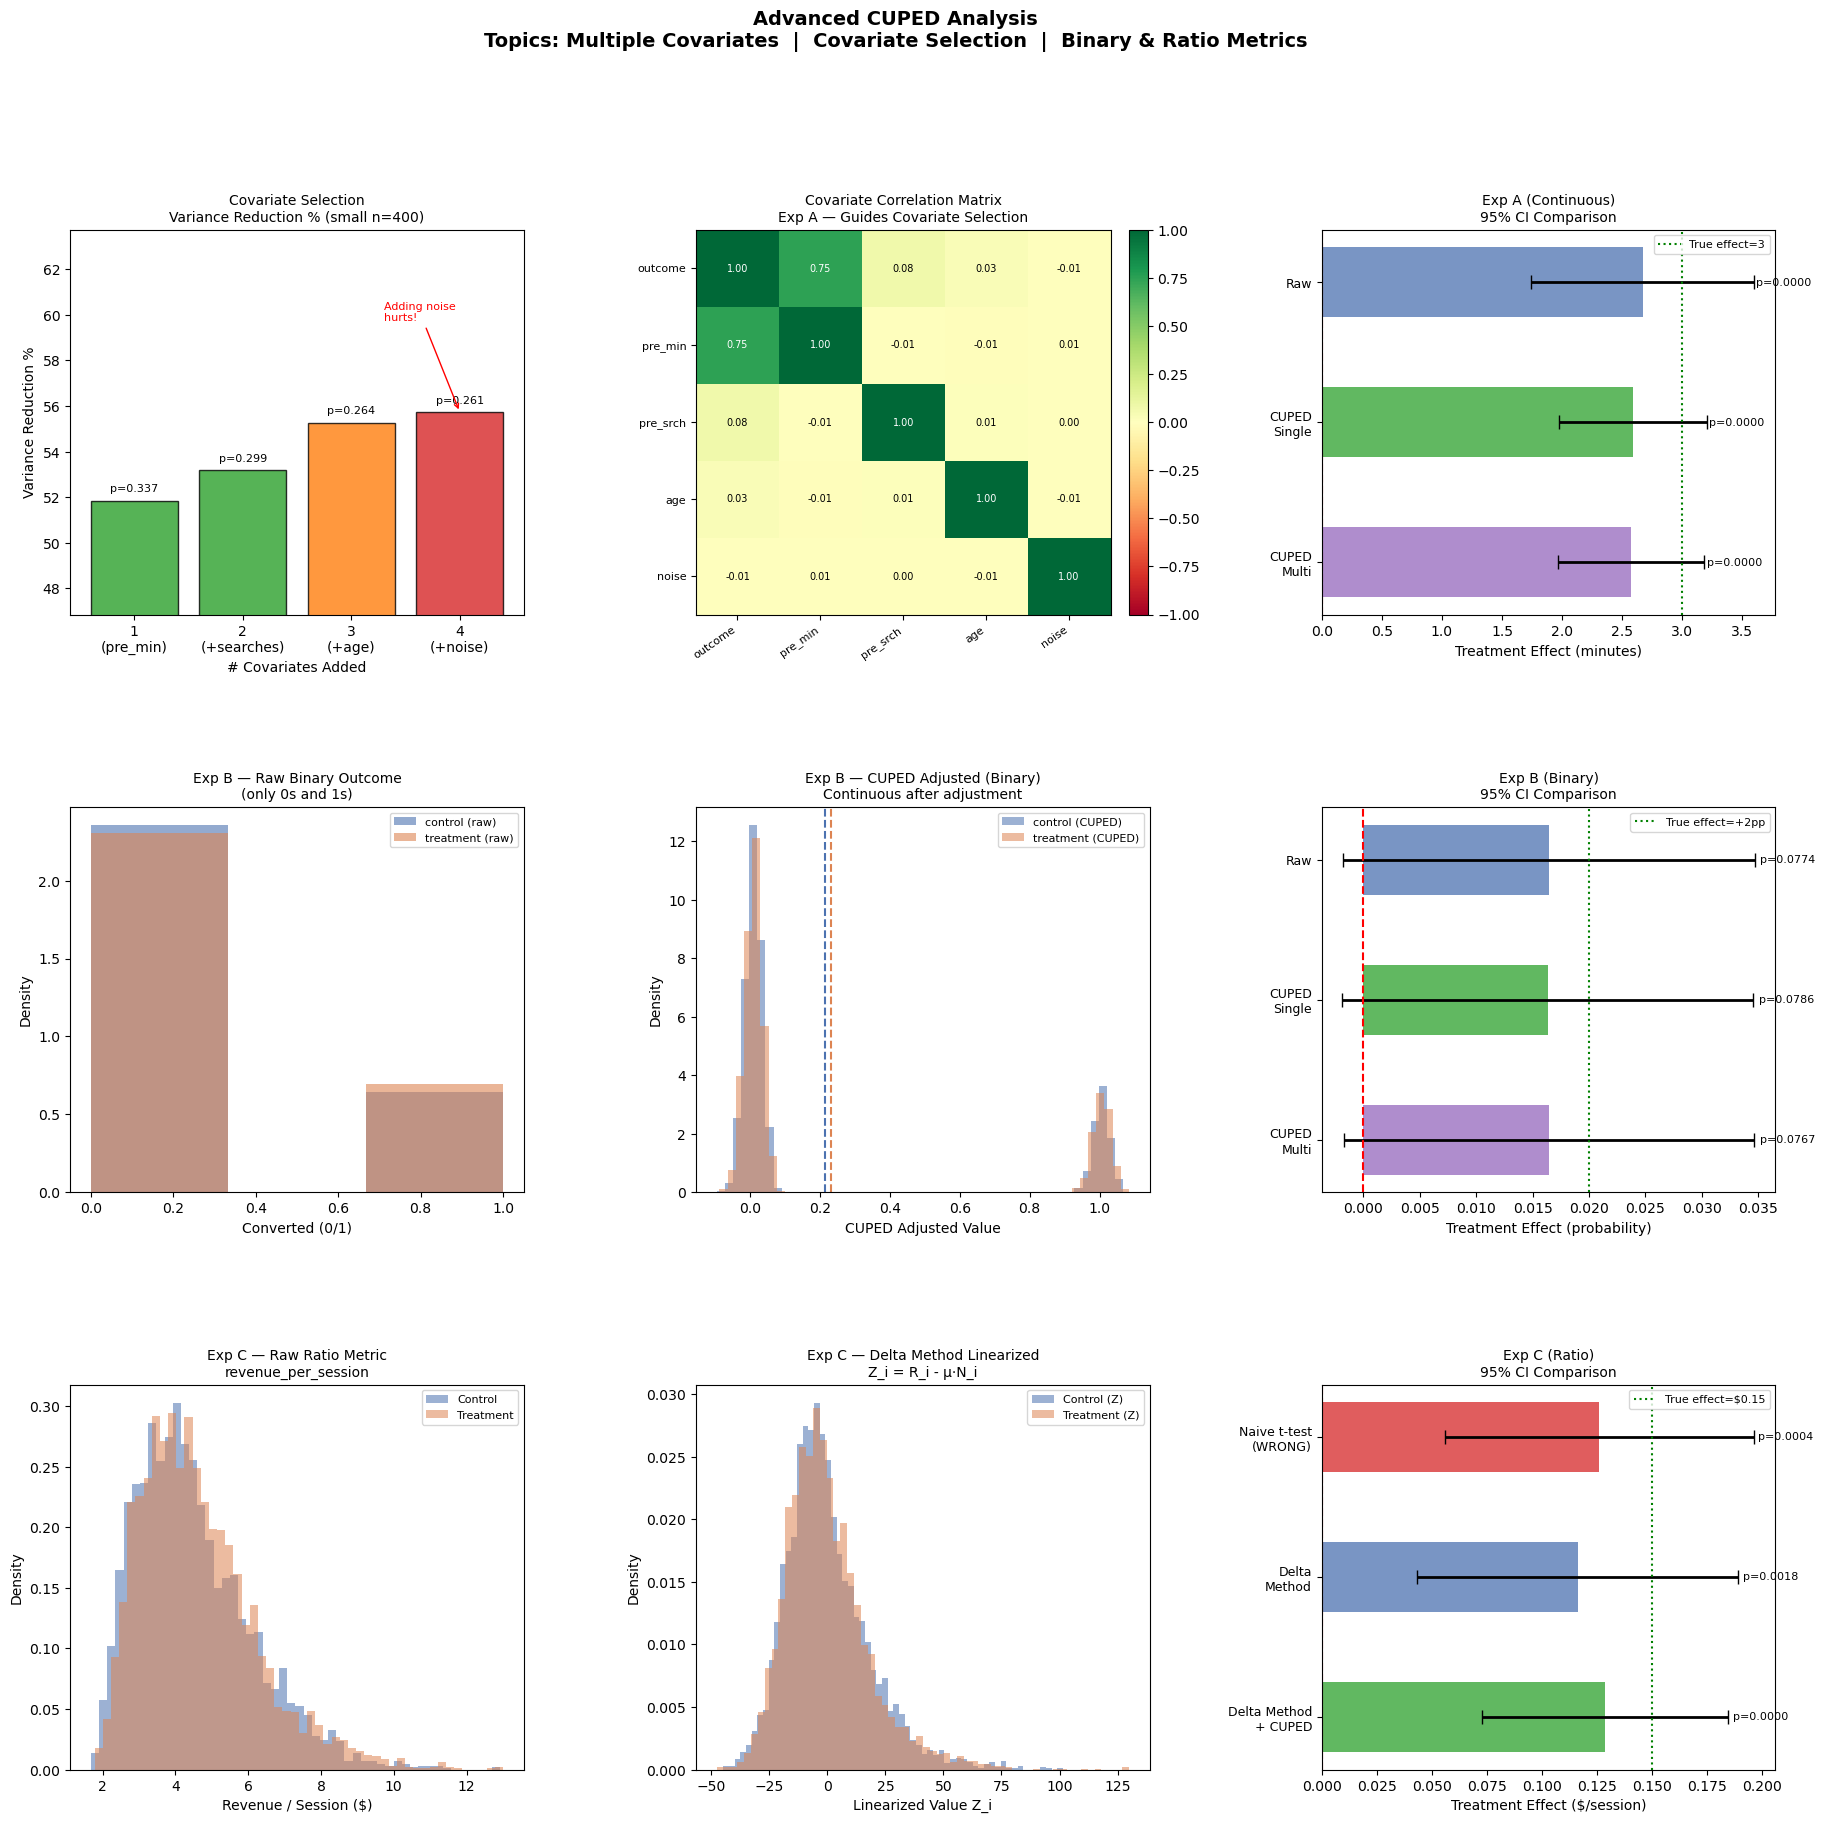

In [53]:
fig = plt.figure(figsize=(22, 20))
fig.suptitle(
    "Advanced CUPED Analysis\n"
    "Topics: Multiple Covariates  |  Covariate Selection  |  Binary & Ratio Metrics",
    fontsize=14, fontweight='bold', y=0.99
)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.50, wspace=0.38)
colors = {'control': '#4C72B0', 'treatment': '#DD8452'}

# ── Plot 1: Covariate Selection — Variance Reduction vs #Covariates ──────────
ax1 = fig.add_subplot(gs[0, 0])
labels_short = ['1\n(pre_min)', '2\n(+searches)', '3\n(+age)', '4\n(+noise)']
vr_vals = []
p_vals_cov = []
for res in cov_results.values():
    raw_std_sm = small_A.loc[small_A['group']=='control', 'outcome'].std(ddof=1)
    vr_vals.append(res['vr'])
    p_vals_cov.append(res['p_value'])

bar_colors = ['#2ca02c', '#2ca02c', '#ff7f0e', '#d62728']
bars = ax1.bar(labels_short, vr_vals, color=bar_colors, alpha=0.8, edgecolor='black')
ax1.axhline(0, color='black', linewidth=0.8)
for bar, p in zip(bars, p_vals_cov):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'p={p:.3f}', ha='center', va='bottom', fontsize=8)
ax1.set_title("Covariate Selection\nVariance Reduction % (small n=400)", fontsize=10)
ax1.set_xlabel("# Covariates Added")
ax1.set_ylabel("Variance Reduction %")
ax1.set_ylim(min(vr_vals) - 5, max(vr_vals) + 8)
ax1.annotate('Adding noise\nhurts!', xy=(3, vr_vals[3]),
             xytext=(2.3, vr_vals[3]+4),
             arrowprops=dict(arrowstyle='->', color='red'),
             fontsize=8, color='red')


# ── Plot 2: Correlation heatmap — Exp A covariates ───────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
cols_corr = ['outcome','pre_minutes','pre_searches','account_age_days','random_noise_col']
corr_matrix = df_A[cols_corr].corr()
im = ax2.imshow(corr_matrix.values, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)
tick_labels = ['outcome','pre_min','pre_srch','age','noise']
ax2.set_xticks(range(len(tick_labels)))
ax2.set_yticks(range(len(tick_labels)))
ax2.set_xticklabels(tick_labels, rotation=35, ha='right', fontsize=8)
ax2.set_yticklabels(tick_labels, fontsize=8)
for i in range(len(cols_corr)):
    for j in range(len(cols_corr)):
        ax2.text(j, i, f"{corr_matrix.values[i,j]:.2f}",
                 ha='center', va='center', fontsize=7,
                 color='black' if abs(corr_matrix.values[i,j]) < 0.7 else 'white')
ax2.set_title("Covariate Correlation Matrix\nExp A — Guides Covariate Selection", fontsize=10)

# ── Plot 3: Exp A — CI comparison Raw vs Single vs Multi ─────────────────────
ax3 = fig.add_subplot(gs[0, 2])
methods_A = ['Raw', 'CUPED\nSingle', 'CUPED\nMulti']
diffs_A   = [res_A_raw['diff'],    res_A_single['diff'],    res_A_multi['diff']]
ci_lo_A   = [res_A_raw['ci_low'],  res_A_single['ci_low'],  res_A_multi['ci_low']]
ci_hi_A   = [res_A_raw['ci_high'], res_A_single['ci_high'], res_A_multi['ci_high']]
p_A       = [res_A_raw['p_value'], res_A_single['p_value'], res_A_multi['p_value']]
bar_c     = ['#4C72B0', '#2ca02c', '#9467bd']
y_pos_A   = [2, 1, 0]
for y, d, lo, hi, p, c, m in zip(y_pos_A, diffs_A, ci_lo_A, ci_hi_A, p_A, bar_c, methods_A):
    ax3.barh(y, d, xerr=[[d-lo],[hi-d]], height=0.5, color=c, alpha=0.75,
             error_kw=dict(ecolor='black', capsize=5, linewidth=2))
    ax3.text(hi+0.02, y, f"p={p:.4f}", va='center', fontsize=8)
ax3.axvline(0, color='red', linestyle='--', linewidth=1.5)
ax3.axvline(3, color='green', linestyle=':', linewidth=1.5, label='True effect=3')
ax3.set_yticks(y_pos_A); ax3.set_yticklabels(methods_A, fontsize=9)
ax3.set_xlabel("Treatment Effect (minutes)")
ax3.set_title("Exp A (Continuous)\n95% CI Comparison", fontsize=10)
ax3.legend(fontsize=8)

# ── Plot 4: Binary outcome — distribution of CUPED adjusted values ───────────
ax4 = fig.add_subplot(gs[1, 0])
for grp, c in colors.items():
    vals_raw  = df_B.loc[df_B['group']==grp, 'outcome']
    ax4.hist(vals_raw, bins=3, alpha=0.6, color=c, label=f"{grp} (raw)", density=True)
ax4.set_title("Exp B — Raw Binary Outcome\n(only 0s and 1s)", fontsize=10)
ax4.set_xlabel("Converted (0/1)")
ax4.set_ylabel("Density")
ax4.legend(fontsize=8)

ax5 = fig.add_subplot(gs[1, 1])
for grp, c in colors.items():
    col_name = 'cuped_multi'
    vals_adj = df_B.loc[df_B['group']==grp, col_name]
    ax5.hist(vals_adj, bins=50, alpha=0.55, color=c, label=f"{grp} (CUPED)", density=True)
ax5.axvline(res_B_raw['mean_ctrl'],   color=colors['control'],   linestyle='--', linewidth=1.5)
ax5.axvline(res_B_raw['mean_treat'],  color=colors['treatment'],  linestyle='--', linewidth=1.5)
ax5.set_title("Exp B — CUPED Adjusted (Binary)\nContinuous after adjustment", fontsize=10)
ax5.set_xlabel("CUPED Adjusted Value")
ax5.set_ylabel("Density")
ax5.legend(fontsize=8)

# ── Plot 5: Binary CI comparison ─────────────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
methods_B = ['Raw', 'CUPED\nSingle', 'CUPED\nMulti']
diffs_B = [res_B_raw['diff'], res_B_single['diff'], res_B_multi['diff']]
ci_lo_B = [res_B_raw['ci_low'], res_B_single['ci_low'], res_B_multi['ci_low']]
ci_hi_B = [res_B_raw['ci_high'], res_B_single['ci_high'], res_B_multi['ci_high']]
p_B     = [res_B_raw['p_value'], res_B_single['p_value'], res_B_multi['p_value']]
bar_c   = ['#4C72B0', '#2ca02c', '#9467bd']
y_pos_B = [2, 1, 0]
for y, d, lo, hi, p, c in zip(y_pos_B, diffs_B, ci_lo_B, ci_hi_B, p_B, bar_c):
    ax6.barh(y, d, xerr=[[d-lo],[hi-d]], height=0.5, color=c, alpha=0.75,
             error_kw=dict(ecolor='black', capsize=5, linewidth=2))
    ax6.text(hi+0.0005, y, f"p={p:.4f}", va='center', fontsize=8)
ax6.axvline(0, color='red', linestyle='--', linewidth=1.5)
ax6.axvline(0.02, color='green', linestyle=':', linewidth=1.5, label='True effect=+2pp')
ax6.set_yticks(y_pos_B); ax6.set_yticklabels(methods_B, fontsize=9)
ax6.set_xlabel("Treatment Effect (probability)")
ax6.set_title("Exp B (Binary)\n95% CI Comparison", fontsize=10)
ax6.legend(fontsize=8)

# ── Plot 6: Ratio metric — naive vs delta method linearized distribution ──────
ax7 = fig.add_subplot(gs[2, 0])
for grp, c in colors.items():
    vals = df_C.loc[df_C['group']==grp, 'outcome']
    ax7.hist(vals, bins=50, alpha=0.55, color=c, label=grp.capitalize(), density=True)
ax7.set_title("Exp C — Raw Ratio Metric\nrevenue_per_session", fontsize=10)
ax7.set_xlabel("Revenue / Session ($)")
ax7.set_ylabel("Density")
ax7.legend(fontsize=8)

ax8 = fig.add_subplot(gs[2, 1])
mask_c = df_C['group'] == 'control'
mask_t = df_C['group'] == 'treatment'
Z_c_raw = res_C_delta['Z_ctrl']
Z_t_raw = res_C_delta['Z_treat']
ax8.hist(Z_c_raw,   bins=60, alpha=0.55, color=colors['control'],   label='Control (Z)', density=True)
ax8.hist(Z_t_raw,   bins=60, alpha=0.55, color=colors['treatment'],  label='Treatment (Z)', density=True)
ax8.set_title("Exp C — Delta Method Linearized\nZ_i = R_i - μ·N_i", fontsize=10)
ax8.set_xlabel("Linearized Value Z_i")
ax8.set_ylabel("Density")
ax8.legend(fontsize=8)

# ── Plot 7: Ratio metric — CI comparison all three methods ───────────────────
ax9 = fig.add_subplot(gs[2, 2])
methods_C = ['Naive t-test\n(WRONG)', 'Delta\nMethod', 'Delta Method\n+ CUPED']
diffs_C = [res_C_naive['diff'], res_C_delta['diff'], res_C_cuped['diff']]
ci_lo_C = [res_C_naive['ci_low'], res_C_delta['ci_low'], res_C_cuped['ci_low']]
ci_hi_C = [res_C_naive['ci_high'], res_C_delta['ci_high'], res_C_cuped['ci_high']]
p_C     = [res_C_naive['p_value'], res_C_delta['p_value'], res_C_cuped['p_value']]
bar_c   = ['#d62728', '#4C72B0', '#2ca02c']
y_pos_C = [2, 1, 0]
for y, d, lo, hi, p, c in zip(y_pos_C, diffs_C, ci_lo_C, ci_hi_C, p_C, bar_c):
    ax9.barh(y, d, xerr=[[d-lo],[hi-d]], height=0.5, color=c, alpha=0.75,
             error_kw=dict(ecolor='black', capsize=5, linewidth=2))
    ax9.text(hi+0.002, y, f"p={p:.4f}", va='center', fontsize=8)
ax9.axvline(0,    color='red',   linestyle='--', linewidth=1.5)
ax9.axvline(0.15, color='green', linestyle=':',  linewidth=1.5, label='True effect=$0.15')
ax9.set_yticks(y_pos_C); ax9.set_yticklabels(methods_C, fontsize=9)
ax9.set_xlabel("Treatment Effect ($/session)")
ax9.set_title("Exp C (Ratio)\n95% CI Comparison", fontsize=10)
ax9.legend(fontsize=8)

plt.show()

In [ ]:
#Row/column "outcome" is what you care about most. Any covariate with a high correlation to outcome (say > 0.3) is a good candidate. 
# Any covariate with near-zero correlation to outcome (like random_noise_col ≈ 0.00) is useless for CUPED.

#The off-diagonal covariate-to-covariate correlations matter too. 
#If pre_minutes and pre_searches are themselves highly correlated (say ρ = 0.8), 
# then including both gives you almost no extra variance reduction — they're explaining the same underlying thing. You'd pick just one.


In [ ]:
# Experiment A (top plot) — all three p = 0.0000, all significant:
# The bar shows the estimated treatment effect, the mean difference.
# The black whisker is the 95% CI. The green dotted line is the true effect = 3 minutes.
#
# Notice:
#
# All three bars end around 2.6 — all are slightly underestimating
# the true effect of 3. This is normal sampling variation, not a bug.
#
# The whisker on Raw is widest — it extends furthest right, past 3.5.
# That wide whisker means high uncertainty.
#
# CUPED Single whisker is narrower — pulled in from the right.
#
# CUPED Multi whisker is narrowest — tightest CI of the three.
#
# All three are significant here because n = 8000 is large enough
# that even the raw test has enough power. CUPED's benefit would
# be more dramatic at n = 1000 or n = 2000 — it would be the
# difference between significant and not.
# Raw says: "the true effect is somewhere between 1 and 3.5 minutes."
# CUPED Multi says: "the true effect is somewhere between 1.9 and 3.1 minutes."
#
# Experiment B (bottom plot) — none are significant, all p ≈ 0.077:
# The red dashed line is zero, no effect. The green dotted line
# is the true effect = +2pp.
#
# All three bars are roughly the same size, and all three whiskers
# cross zero, the red dashed line. Crossing zero means you cannot
# rule out no effect — hence not significant.
#
# The key observation: CUPED barely helped here.